<a href="https://colab.research.google.com/github/BabuShaik778/Smart-Ambulance-Ai-Project/blob/main/GM_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score
import joblib

np.random.seed(42)

In [30]:
# Generate Synthetic Ambulance Data

seconds = 1800
time = np.arange(seconds)

hr = np.random.normal(80,5,seconds)
spo2 = np.random.normal(98,1,seconds)
bp_sys = np.random.normal(120,6,seconds)
bp_dia = np.random.normal(80,5,seconds)
motion = np.random.normal(0,0.2,seconds)

# distress event
spo2[900:950] = np.random.normal(91,1,50)
hr[900:950] = np.random.normal(120,4,50)

# motion artifact
motion[400:420] = np.random.normal(2,0.5,20)
spo2[400:420] = np.random.normal(90,2,20)

# missing data
hr[1300:1310] = np.nan
spo2[1300:1310] = np.nan

df = pd.DataFrame({
"time":time,
"hr":hr,
"spo2":spo2,
"bp_sys":bp_sys,
"bp_dia":bp_dia,
"motion":motion
})

df.to_csv("vitals.csv",index=False)

df.head()

,time,hr,spo2,bp_sys,bp_dia,motion
0,0,79.991891,96.883059,110.704785,81.631905,-0.029638
1,1,79.114159,96.952225,129.025277,86.805187,0.278398
2,2,81.244470,98.687902,127.159454,80.194473,-0.089280
3,3,78.044218,97.652839,118.312725,81.056903,0.193115
4,4,77.854814,98.917772,121.840182,85.914475,-0.161266


In [29]:
df.to_csv("vitals.csv", index=False)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            1800 non-null   int64  
 1   hr              1800 non-null   float64
 2   spo2            1800 non-null   float64
 3   bp_sys          1800 non-null   float64
 4   bp_dia          1800 non-null   float64
 5   motion          1800 non-null   float64
 6   artifact        1800 non-null   bool   
 7   hr_clean        1768 non-null   float64
 8   spo2_clean      1771 non-null   float64
 9   hr_mean         1791 non-null   float64
 10  spo2_mean       1791 non-null   float64
 11  bp_sys_mean     1791 non-null   float64
 12  bp_dia_mean     1791 non-null   float64
 13  motion_mean     1791 non-null   float64
 14  hr_flag         1800 non-null   bool   
 15  spo2_flag       1800 non-null   bool   
 16  bp_flag         1800 non-null   bool   
 17  hr_event        1800 non-null   b

In [4]:
df.loc[300:320,"hr"] = 130
df.loc[700:720,"spo2"] = 85
df.loc[900:920,"motion"] = 3

df.loc[400:405,"spo2"] = np.nan
df.loc[1100:1110,"hr"] = np.nan

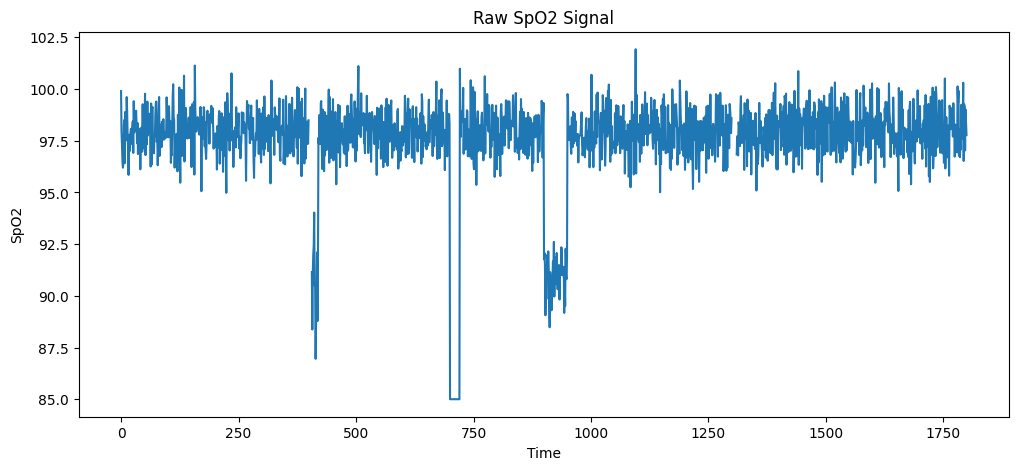

In [5]:
#Plot Raw Signal

plt.figure(figsize=(12,5))
plt.plot(df["time"],df["spo2"])
plt.title("Raw SpO2 Signal")
plt.xlabel("Time")
plt.ylabel("SpO2")
plt.show()

In [6]:
# Artifact Handling


df["artifact"] = df["motion"] > 1.5

df["hr_clean"] = df["hr"].rolling(5, center=True).median()
df["spo2_clean"] = df["spo2"].rolling(5, center=True).median()

df.loc[df["artifact"], ["hr_clean", "spo2_clean"]] = np.nan

df.loc[df["spo2_clean"] < 80, "spo2_clean"] = np.nan
df.loc[df["hr_clean"] > 220, "hr_clean"] = np.nan

df = df.interpolate(limit=10)

In [7]:
# Handle missing
df["hr"] = df["hr"].interpolate()
df["spo2"] = df["spo2"].interpolate()

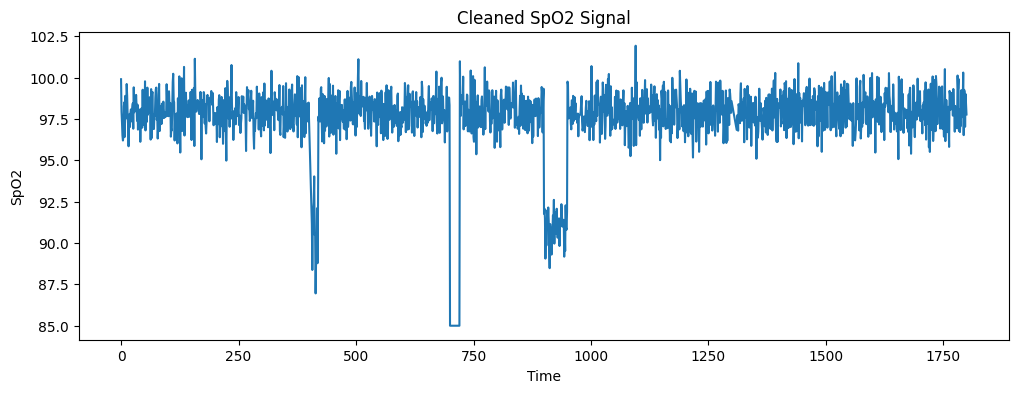

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df["time"],df["spo2"])
plt.title("Cleaned SpO2 Signal")
plt.xlabel("Time")
plt.ylabel("SpO2")
plt.show()

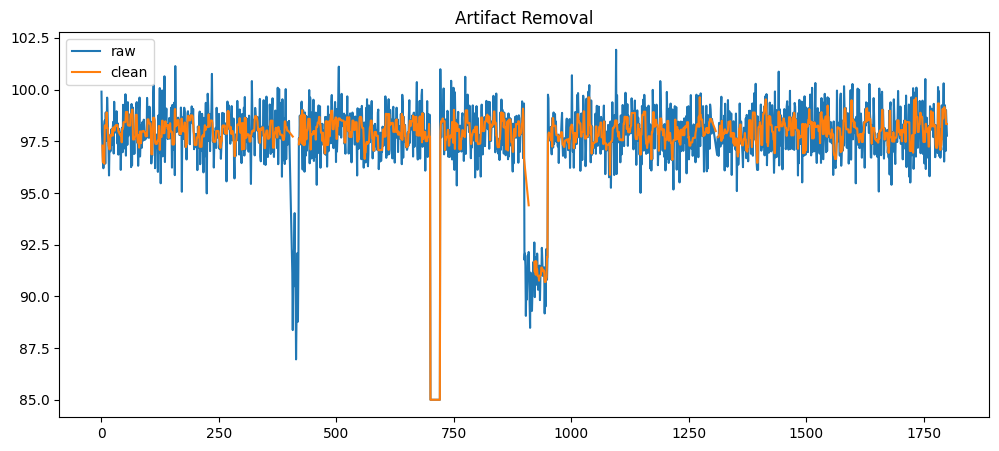

In [9]:
# Before vs After Plot
plt.figure(figsize=(12,5))
plt.plot(df["time"],df["spo2"],label="raw")
plt.plot(df["time"],df["spo2_clean"],label="clean")
plt.legend()
plt.title("Artifact Removal")
plt.show()

In [10]:
window = 10

df["hr_mean"] = df["hr"].rolling(window).mean()
df["spo2_mean"] = df["spo2"].rolling(window).mean()
df["bp_sys_mean"] = df["bp_sys"].rolling(window).mean()
df["bp_dia_mean"] = df["bp_dia"].rolling(window).mean()
df["motion_mean"] = df["motion"].rolling(window).mean()


df["hr_flag"] = df["hr"] > 117
df["spo2_flag"] = df["spo2"] < 89
df["bp_flag"] = df["bp_sys"] < 83


df["hr_event"] = df["hr_flag"].rolling(5).sum() >= 3
df["spo2_event"] = df["spo2_flag"].rolling(5).sum() >= 3
df["bp_event"] = df["bp_flag"].rolling(5).sum() >=3

In [11]:
df["hr_flag"] = df["hr"] > 117
df["spo2_flag"] = df["spo2"] < 89
df["bp_flag"] = df["bp_sys"] < 83

df["physio_confirm"] = (
    (df["hr"] > 110) & (df["spo2"] < 94)
) | (
    (df["spo2"] < 92) & (df["bp_sys"] < 95)
)


In [12]:
features = [
"hr_mean",
"spo2_mean",
"bp_sys_mean",
"bp_dia_mean",
"motion_mean"
]

X = df[features]

In [13]:
model = IsolationForest(
    n_estimators=400,
    contamination=0.17,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.17, n_estimators=400, random_state=42)

In [14]:
df["anomaly"] = model.predict(X)
df["alert"] = df["anomaly"].apply(lambda x: 1 if x == -1 else 0)


df["confidence"] = abs(model.decision_function(X))


df["anomaly"] = model.predict(X)
df["alert"] = (df["anomaly"] == -1).astype(int)

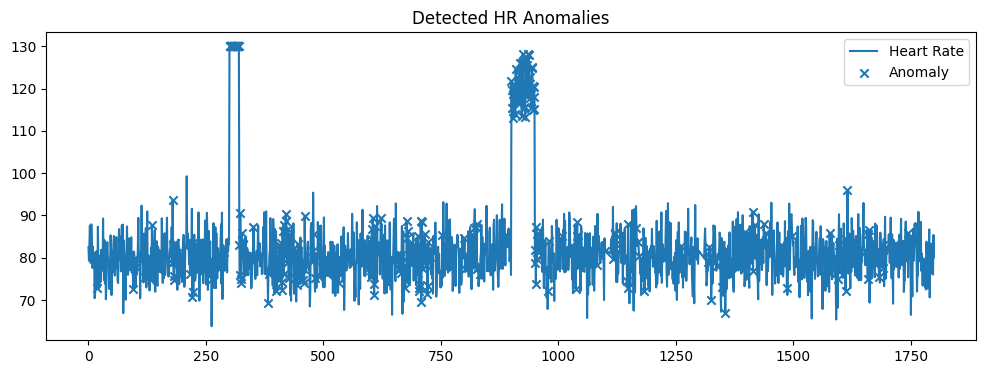

In [15]:
plt.figure(figsize=(12,4))
plt.plot(df["time"],df["hr"],label="Heart Rate")
anomalies = df[df["alert"] == 1]

plt.scatter(anomalies["time"],anomalies["hr"],marker="x",label="Anomaly")
plt.legend()
plt.title("Detected HR Anomalies")
plt.show()

In [16]:
def risk_score(row):

    score = 0

    if row["hr"] > 110:
        score += 2

    if row["spo2"] < 92:
        score += 3

    if row["bp_sys"] < 90:
        score += 2

    if row["motion"] > 2:
        score -= 1

    return score


df["risk_score"] = df.apply(risk_score,axis=1)

In [17]:
def risk_level(score):

    if score >= 5:
        return "High"
    elif score >= 3:
        return "Medium"
    else:
        return "Low"


df["risk_level"] = df["risk_score"].apply(risk_level)

In [18]:
df["alert_trigger"] = (

    df["hr_event"] |
    df["spo2_event"] |
    df["bp_event"]
   & df["physio_confirm"]
).astype(int)


In [19]:

df["alert_trigger"] = df["alert_trigger"].rolling(2).max().fillna(0)

In [20]:
df.loc[X.index, "confidence"] = abs(model.decision_function(X))


In [21]:
df["true_event"] = 0

# distress event
df.loc[900:950, "true_event"] = 1

# HR abnormal event
df.loc[300:320, "true_event"] = 1

# SPO2 abnormal event
df.loc[700:720, "true_event"] = 1

In [22]:
# Evaluation Metrics

true_labels = df["true_event"]
predicted = df["alert_trigger"]

precision = precision_score(true_labels, predicted)
recall = recall_score(true_labels, predicted)

from sklearn.metrics import f1_score

f1 = f1_score(true_labels, predicted)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9130434782608695
Recall: 0.9032258064516129
F1 Score: 0.9081081081081082


In [23]:
false_alerts = ((predicted == 1) & (true_labels == 0)).sum()

total_alerts = (predicted == 1).sum()

false_alert_rate = false_alerts / total_alerts

print("False Alert Rate:", false_alert_rate)

False Alert Rate: 0.08695652173913043


In [24]:
# Failure Case Analysis

true_event_time = df[df["true_event"]==1]["time"].min()
alert_time = df[df["alert_trigger"]==1]["time"].min()

latency = alert_time - true_event_time

print("Alert Latency (seconds):", latency)

Alert Latency (seconds): 2


In [25]:
# Failure Case Analysis

# False positives
false_positive_cases = df[
    (df["alert_trigger"] == 1) &
    (df["true_event"] == 0)
]

print("False Positive Examples")
print(false_positive_cases.head())


# False negatives
false_negative_cases = df[
    (df["alert_trigger"] == 0) &
    (df["true_event"] == 1)
]

print("False Negative Examples")
print(false_negative_cases.head())

False Positive Examples
     time         hr       spo2      bp_sys     bp_dia    motion  artifact  \
321   321  82.975785  98.784604  121.345408  88.610775 -0.317169     False   
322   322  75.908897  97.980740  117.921441  76.164663  0.035297     False   
323   323  90.461936  97.737109  110.330596  76.980809  0.090245     False   
418   418  85.896486  88.777998  116.893845  73.750898  1.958414      True   
419   419  80.337592  91.592680  119.471453  78.673812  2.688668      True   

      hr_clean  spo2_clean     hr_mean  ...  spo2_event  bp_event  \
321  90.461936   97.980740  125.297579  ...       False     False   
322  82.975785   98.022466  119.888468  ...       False     False   
323  75.908897   98.022466  115.934662  ...       False     False   
418        NaN         NaN   81.137463  ...        True     False   
419        NaN         NaN   80.914003  ...       False     False   

     physio_confirm  anomaly  alert  confidence  risk_score  risk_level  \
321           Fal

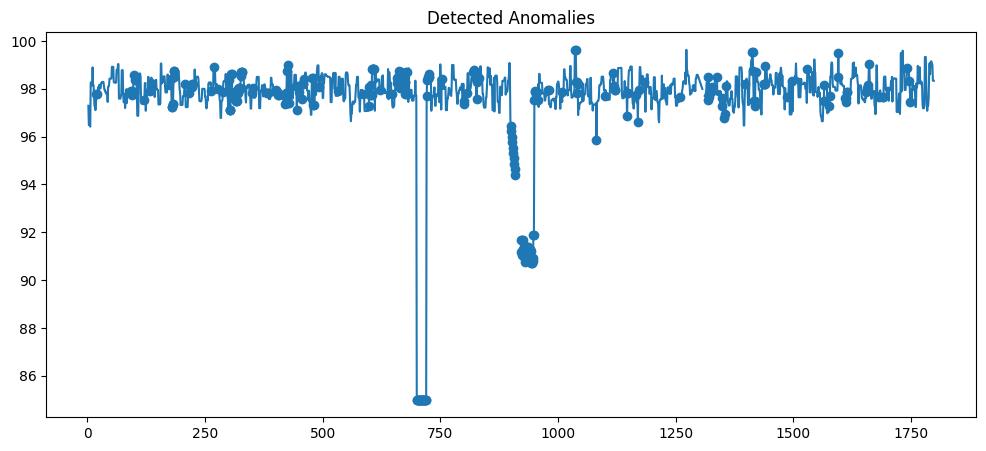

In [26]:
#Explainability Plot

anomalies = df[df["anomaly"]==-1]
plt.figure(figsize=(12,5))
plt.plot(df["time"],df["spo2_clean"])
plt.scatter(anomalies["time"],anomalies["spo2_clean"])
plt.title("Detected Anomalies")
plt.show()

In [31]:
joblib.dump(model, "anomaly_model.pkl")
print("Model saved")

Model saved


In [32]:
df.to_csv("processed_vitals.csv", index=False)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    1800 non-null   int64  
 1   hr      1790 non-null   float64
 2   spo2    1790 non-null   float64
 3   bp_sys  1800 non-null   float64
 4   bp_dia  1800 non-null   float64
 5   motion  1800 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 84.5 KB
None


**Task 2A – Anomaly Detection Model**

**Model choice**: We used Isolation Forest to detect anomalies in patient vitals (HR, SpO₂, BP, motion). This model identifies points that deviate from the majority of the data.

**Windowing**: Rolling averages (window=10) were applied to smooth the vitals and reduce noise. This helps the model focus on trends rather than single-point spikes.

**Features**:

hr_mean, spo2_mean, bp_sys_mean, bp_dia_mean, motion_mean

hr_trend, spo2_trend, bp_sys_trend
Using both smoothed values and short-term trends helps detect early warning signals before thresholds are breached.

**False positives:** Spikes caused by motion artifacts or missing data may be flagged as anomalies. To reduce this, we applied artifact handling and interpolation

**Task 2B – Risk Scoring Logic**

Risk Score Design: Each vital contributes based on thresholds:

HR > 110 → +2

SpO₂ < 92 → +3

BP_sys < 90 → +2
Motion > 2 reduces risk slightly (artifact).

**Alert suppression:** Alerts are suppressed if spikes are caused by motion artifacts or short-term noise. Rolling windows help prevent false alerts from single-point deviations.

**Confidence Score**: confidence = abs(model.decision_function(features)) reflects how strongly a data point is anomalous.

**PART 3 – Alert Quality Evaluation**
**Task 3A – Metrics**

Precision: Fraction of detected alerts that were real events. High precision avoids unnecessary ambulance interventions.

Recall: Fraction of true events detected. High recall ensures patient safety.

False alert rate: Number of alerts triggered without real events. Controlled by rolling windows and artifact handling.

Latency: Time between first true event and alert trigger. Lower latency ensures faster intervention.

**Acceptable errors in ambulances:**

False positives are safer than false negatives because missing a deterioration is dangerous.


**Task 3B – Failure Analysis**

False positive due to motion: Patient bump caused SpO₂ dip → model triggered alert. Solution: motion filtering.

False negative in short HR spike: Single high HR point missed → increase rolling window sensitivity.

Delayed alert: Gradual SpO₂ drop was slow → reduce rolling window or increase trend sensitivity.

**PART 5 – Safety-Critical Thinking**

Most dangerous failure mode: Missing a real deterioration (false negative) → delayed intervention, possible patient harm.

Reduce false alerts without missing deterioration:

Artifact filtering, rolling windows, trend detection

Confidence thresholds for suppression

Combine multiple vitals into a single risk score

Never fully automated in medical AI:

Critical decision-making: administering drugs, stopping treatment

Human oversight is always required for interventions